In [ ]:
# Copyright 2025 United Kingdom Research and Innovation
# Copyright 2025 The University of Manchester
# Copyright 2025 Technical University of Denmark
#
# Author(s):
#   David Wang Johansen, s214743@dtu.dk
#   Martin Sæbye Carøe, msaca@dtu.dk
#   Rasmus Juul Pedersen, rjupe@dtu.dk
#
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#     http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [ ]:
import os
from pathlib import Path, PureWindowsPath

import numpy as np
import matplotlib.pyplot as plt

from cil.framework import AcquisitionData, AcquisitionGeometry, ImageGeometry
from cil.io.TIFF import TIFFStackReader
from cil.utilities.display import show2D, show_geometry, show_system_positions
from cil.utilities.jupyter import islicer
from cil.processors import TransmissionAbsorptionConverter

class NSIDataReader_(object):
    
    def __init__(self, file_name=None, positions_path = None, roi=None, num_proj_subset=None):
        """
        file_name: Should be in the file format .nsipro
        num_proj_subset: number of projections to use starting from the first projection.
            TODO - Extend this to a slice object.
        """
        self.file_name = file_name
        self.num_proj_subset = num_proj_subset
        self.positions_path = positions_path
        
        if file_name is not None:
            self.set_up(file_name=file_name, num_proj_subset=num_proj_subset, roi=roi)
        self.roi = roi
        
    @staticmethod
    def parse_nsipro(file_name):
        with open(file_name, 'r') as f:
            text = f.read()
        lines = [line.rstrip() for line in text.splitlines() if line.strip()]
        root = {}
        stack = [(root, None)]  # (current_dict, current_key)
        
        for line in lines:
            indent = len(line) - len(line.lstrip())
            content = line.strip()
            
            # Adjust stack based on indentation
            while len(stack) > indent // 2 + 1:  # assuming 2 spaces per indent
                stack.pop()
            
            current_dict, current_key = stack[-1]
            
            if content.startswith("</"):
                continue
            
            if content.startswith("<") and ">" in content:
                # Extract tag and value
                tag = content[1:content.find(">")]
                value = content[content.find(">")+1:].strip()
                
                if value:  # tag with value
                    current_dict[tag] = value
                else:  # tag without value (container)
                    if tag in current_dict:
                        # Convert to list if repeated
                        if not isinstance(current_dict[tag], list):
                            current_dict[tag] = [current_dict[tag]]
                        new_dict = {}
                        current_dict[tag].append(new_dict)
                    else:
                        new_dict = {}
                        current_dict[tag] = new_dict
                    stack.append((new_dict, tag))
        
        return root

    def set_up(self, file_name=None, num_proj_subset=None):
        self._metadata = self.parse_nsipro(file_name)['NSI Reconstruction Project']
        self.file_name = file_name
        self.num_proj_subset = num_proj_subset
        self.tiff_directory_path = (Path(file_name).parent / PureWindowsPath(self._metadata['Object Radiograph']['file'])).parent

        if self.file_name == None:
            raise Exception('Path to file is required.')
        
        if not(os.path.isfile(self.file_name)):
            raise Exception('File\n {}\n does not exist.'.format(self.file_name))
        
        self._height_per_rev = float(self._metadata['VorteX']['pitch'])
        self._revs = int(self._metadata['VorteX']['revolutions'])
        self._num_proj = int(self._metadata['Object Radiograph']['number'])
        self._angle_step = self._num_proj / (360 * self._revs)
        self._proj_per_rev = self._num_proj / self._revs
        self._height_per_step = self._height_per_rev / self._proj_per_rev

        if self.num_proj_subset is None:
            self.num_proj_subset = self._num_proj
        self._roi = {'axis_0': (None, num_proj_subset, None), 'axis_1': -1, 'axis_2': -1}

        self._pixel_num_w = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['width pixels'])
        self._pixel_num_h = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['height pixels'])
        microns_to_mm = 0.001
        self._pixel_size_w = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel width microns'])
        self._pixel_size_h = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel height microns'])
        self._src_to_det = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to detector distance'])
        self._src_to_obj = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to table distance'])
        self._obj_to_det = self._src_to_obj - self._src_to_det

        self.N = num_proj_subset if num_proj_subset else self._num_proj
        self._src_pos = np.zeros((self.N,3))
        self._det_pos = np.zeros((self.N,3))
        self._det_x = np.zeros((self.N,3))
        self._det_y = np.zeros((self.N,3))

        def get_rot_mat(ang):
            ang_rad = np.deg2rad(ang)
            c = np.cos(ang_rad)
            s = np.sin(ang_rad)
            Rz = np.array([
                [ c, -s, 0],
                [ s,  c, 0],
                [ 0,  0, 1]
            ])
            return Rz

        self._src_pos[0] = [self._src_to_obj, 0., 0.]
        self._det_pos[0] = [self._obj_to_det, 0., 0.]
        self._det_x[0] = [0., 1, 0]
        self._det_y[0] = [0., 0., 1]
        for i in range(1,self.N):
            h = i * self._height_per_step
            Rz = get_rot_mat(self._angle_step)
            
            self._src_pos[i] = Rz @ self._src_pos[i-1]
            self._det_pos[i] = Rz @ self._det_pos[i-1]
            self._det_x[i] = Rz @ self._det_x[i-1]
            self._det_y[i] = Rz @ self._det_y[i-1]

            self._src_pos[i,2] = h
            self._det_pos[i,2] = h
        
        self._ag = AcquisitionGeometry.create_Cone3D_Flex(self._src_pos, self._det_pos, self._det_x, self._det_y)
        self._ag = self._ag.set_panel((self._pixel_num_w, self._pixel_num_h), (self._pixel_size_w, self._pixel_size_h), origin='bottom-right')

    def get_geometry(self, index=None):
        """
        Return AcquisitionGeometry object.
        index=None returns the flex geometry
        while setting it to an integer returns the geometry at that specific angle.
        """
        if index is None:
            return self._ag
        
        ag = AcquisitionGeometry.create_Cone3D(
            self._src_pos[index],
            self._det_pos[index],
            self._det_x[index],
            self._det_y[index],
        ).set_panel(
            (self._pixel_num_w, self._pixel_num_h), (self._pixel_size_w, self._pixel_size_h)
        ).set_angles([index*self._angle_step])
        return ag
    
    def get_image_geometry(self):
        """
        Currently hard-coded.
        """
        # min_height = self._pixel_num_h // 2
        # extra_height = int(self._height_per_step * self.N / self._pixel_size_w)
        # pixel_height = min_height + extra_height
        # magnification = np.abs(self._obj_to_det / self._src_to_obj)
        # ig = ImageGeometry(
        #     self._pixel_num_w, self._pixel_num_w, pixel_height, # voxel nums
        #     self._pixel_size_w, self._pixel_size_w, self._pixel_size_w, # voxel sizes
        #     center_z=self._pixel_size_w * extra_height / 2
        # )
        size = 0.05
        ig = ImageGeometry(
            self._pixel_num_w, self._pixel_num_w, int(75/size), # voxel nums
            size, size, size, # voxel sizes
            center_z=22.5
        )
        return ig
    
    def read(self):
        """
        Reads projections and return AcquisitionData container
        """
        tiff_reader = TIFFStackReader(file_name=self.tiff_directory_path, roi=self._roi)
        self._arr = tiff_reader.read()
        self._arr = self._arr[:,::-1,:] # vertical direction seems to be flipped
        self._ad = AcquisitionData(array=self._arr, geometry=self._ag)
        return self._ad

In [2]:
def plot_3d_paths(coords1, coords2, label1="Path 1", label2="Path 2"):
    x1, y1, z1 = coords1[:, 0], coords1[:, 1], coords1[:, 2]
    x2, y2, z2 = coords2[:, 0], coords2[:, 1], coords2[:, 2]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(x1, y1, z1, label=label1)
    ax.plot(x2, y2, z2, label=label2)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.legend()
    plt.show()

In [3]:
from pathlib import Path
BASE_PATH = Path("/work3/s164564/CIL-Reader-Showcase/data/NSI-data")
FILE_NAME = "Demo_BabeRuth - PreReconstruction.nsipro"
DATA_PATH = BASE_PATH / FILE_NAME

In [4]:
metadata = NSIDataReader.parse_nsipro(DATA_PATH)
metadata

{'NSI Reconstruction Project': {'version': '2.0',
  'Project Name': 'Demo_BabeRuth',
  'Project Folder': 'Z:\\Training\\Demo_BabeRuth',
  'Creation Date': '11/5/2024 11:28:36 AM',
  'Comments': 'Helical Step scan completed at 11/5/2024 2:18:36 PM',
  'VorteX': {'height': '180.13045',
   'pitch': '15.0108708333333',
   'revolutions': '12',
   'sets': '3',
   'set height': '60.0434833333333',
   'revolutions per set': '4',
   'sigma': '50.0362361111111'},
  'Object Radiograph': {'file': 'Radiographs-Demo_BabeRuth\\Demo_BabeRuth-radio*.tif',
   'pitch': '0.2 0.2',
   'sort numerically': 'True',
   'number': '4320',
   'angleStep': '0.999306037473976'},
  'Correction': {'already masked': 'False',
   'flipH': 'False',
   'flipV': 'False',
   'rotate': '0',
   'crop': '40 40 40 40'},
  'Geometry Correction Steps': {'center': '0 0.0417065177124334 0',
   'source': '0 0.0417065177124334 0',
   'reference': '0 0.0417065177124334 0',
   'normal': '0 0 0',
   'horizontal': '0 0 0'},
  'CT Project

In [5]:
reader = NSIDataReader(file_name=DATA_PATH, num_proj_subset=3*360)
ig = reader.get_image_geometry()

In [6]:
ig.shape

(1500, 1536, 1536)

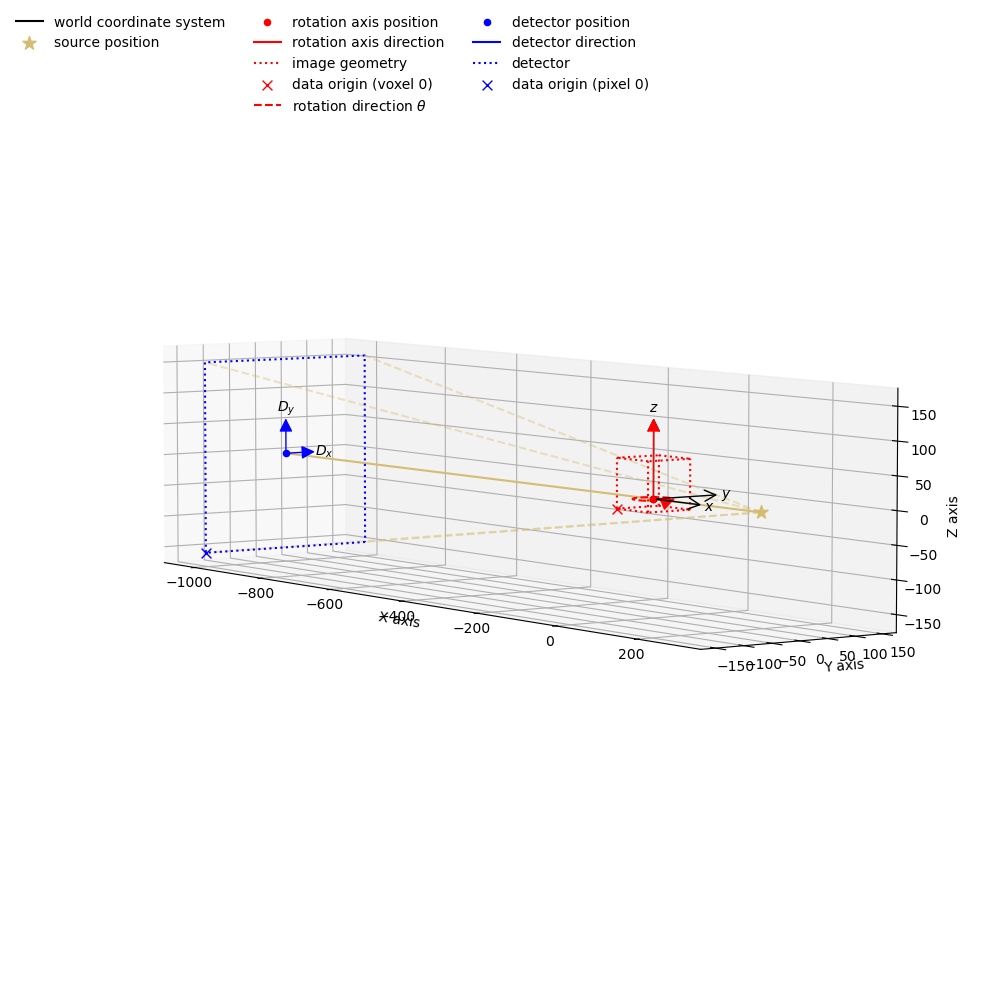

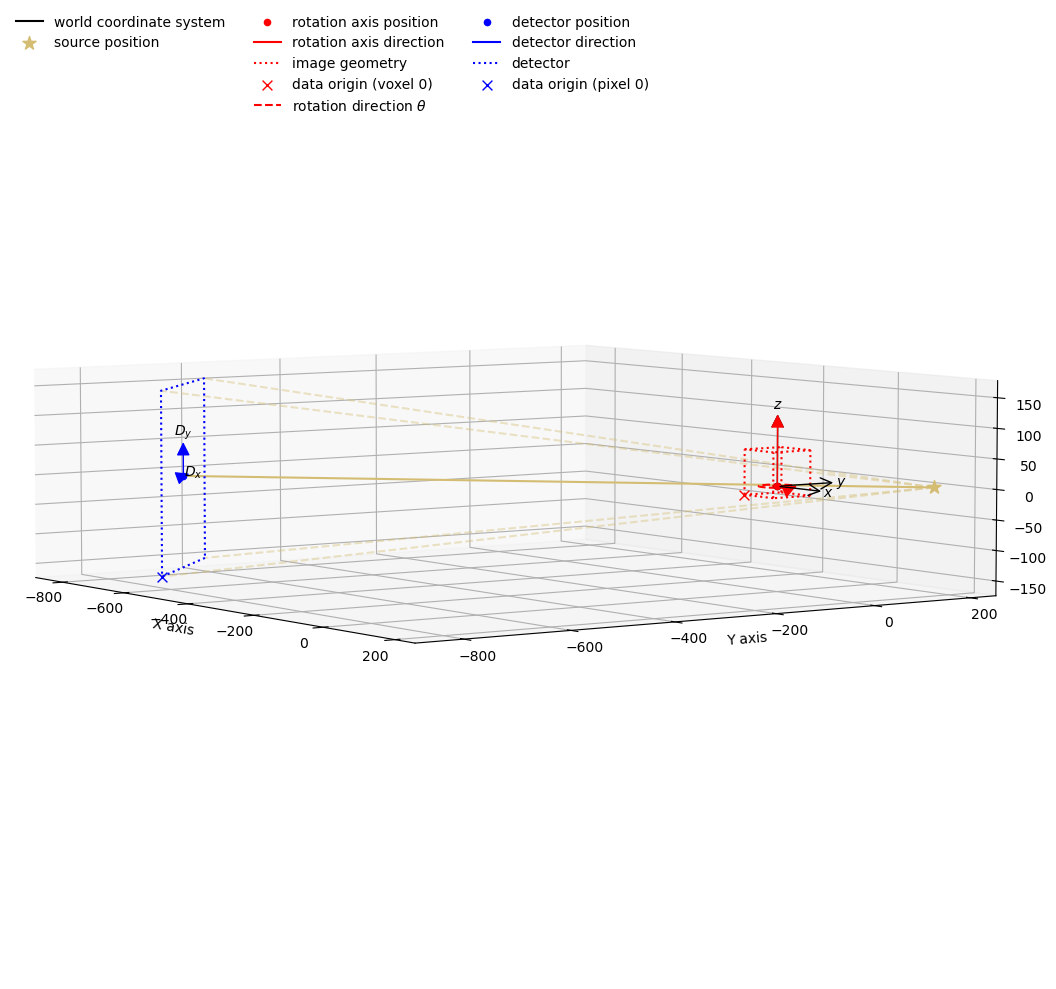

In [ ]:
show_geometry(reader.get_geometry(0), ig, grid=True, elevation=5)
show_geometry(reader.get_geometry(45), ig, grid=True, elevation=5)

In [8]:
# import ipywidgets as widgets
# from ipywidgets import interact

# def view_geometry(i):
#     g = reader.get_geometry(i)
#     show_geometry(g, ig, grid=True, elevation=5)

# interact(view_geometry, i=widgets.IntSlider(0, 0, 1000, 1))

In [9]:
ad = reader.read()

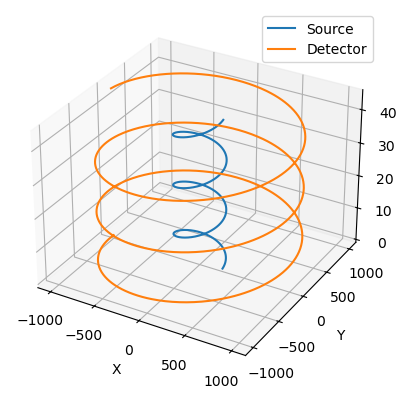

In [10]:
plot_3d_paths(reader._src_pos, reader._det_pos, 'Source' , 'Detector')

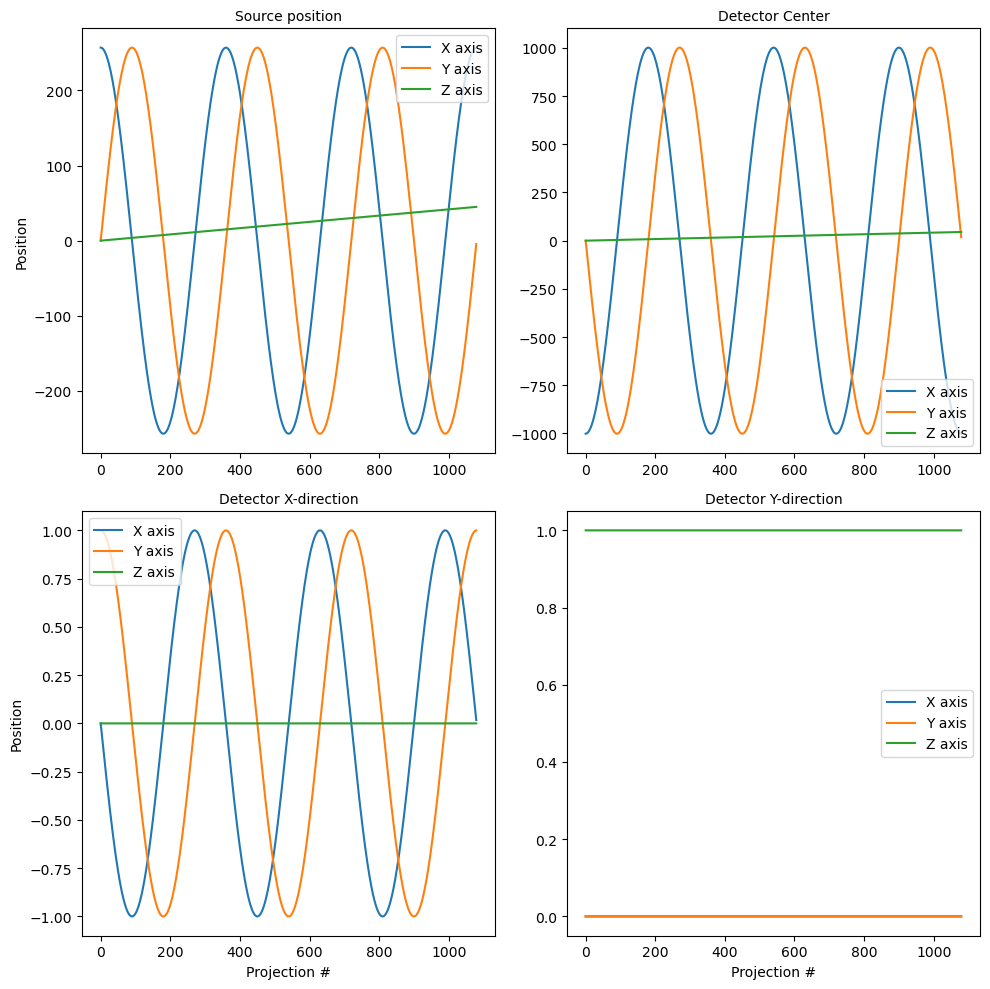

In [11]:
show_system_positions(ad.geometry)

In [12]:
from PIL import Image
flat_field = np.array(Image.open(DATA_PATH.parent / 'Radiographs-Demo_BabeRuth/Demo_BabeRuth-radio_04319.tif'))

In [13]:
ad.array = ad.array / flat_field[::-1,:]
ad = TransmissionAbsorptionConverter(accelerated=False)(ad)

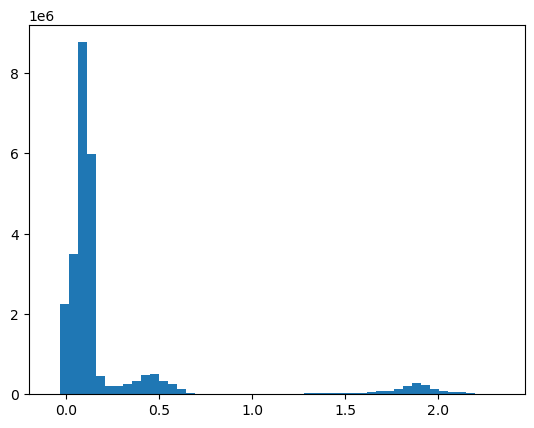

In [14]:
plt.hist(ad.array.ravel()[::100], bins=50)
plt.show()

In [ ]:
islicer(ad, direction=0)

In [16]:
from cil.plugins.astra import FBP
ad.reorder(order='astra')
fbp = FBP(image_geometry=ig, acquisition_geometry=ad.geometry)
fbp.set_input(ad)
recon = fbp.get_output()

In [ ]:
islicer(recon, minmax=(0.,0.03))